In [1]:
from eval_functions.struct_plot_funcitons import *
from eval_functions.struct_latex_functions import *
from eval_functions.struct_json_eval_functions import *
from eval_functions.struct_entity_eval_functions import *
from eval_functions.struct_operator_eval_functions import *

In [2]:
batch_path = "llm_output/std_fine_tuning_70B"
label_folder = "../input/lct_p4" 
models = get_models(f'{batch_path}/model_output/')

### Process Model Outputs: Filter failure model files

In [3]:
for model_name in models:
    model_folder = f"{batch_path}/model_output/{model_name}/output"
    ready_folder = f"{batch_path}/model_output/{model_name}/ready"
    failure_folder = f"{batch_path}/model_output/{model_name}/failure"
    process_failure_folder = f"{batch_path}/model_output/{model_name}/processed_output"
    read_and_process_files(model_path=f"{batch_path}/model_output" ,model_name=model_name) ## Filter Failure Files
    process_all_files_in_directory(ready_folder, process_failure_folder, failure_folder) ## JSON to Text

#### Anzahl der Fehler in der Modelausgabe

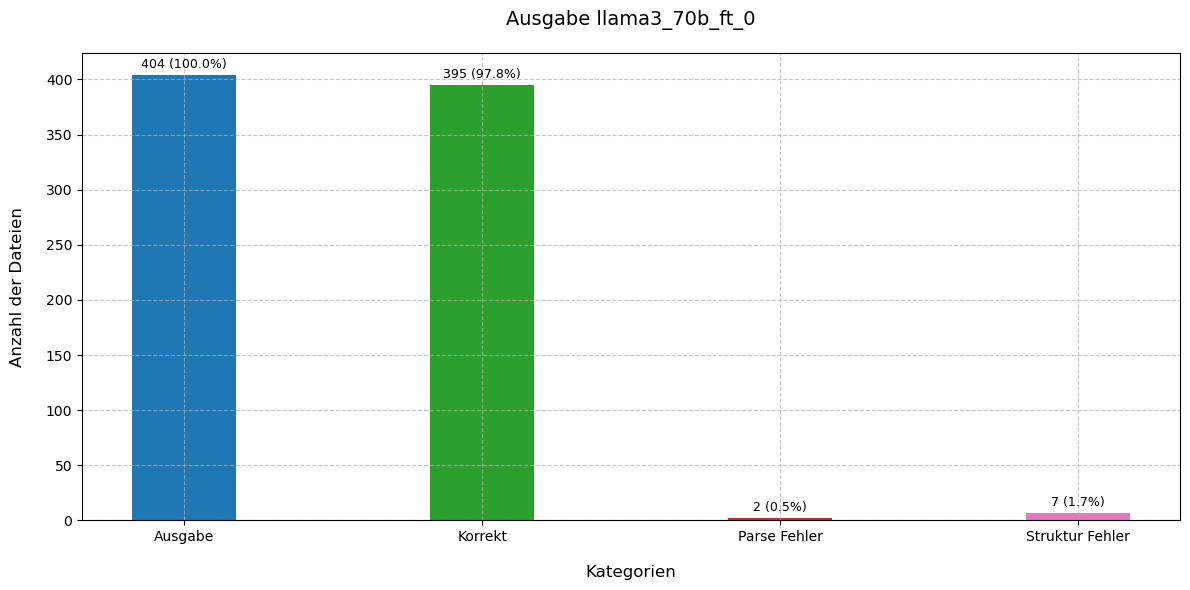

In [4]:
plot_file_counts(models[0], batch_name=batch_path)

### Calculate Entity Metrics and save to Latex

In [6]:
for model in models:
    latex_file_counts_table(model_name=model, batch_path=batch_path)
    ready_folder = f"{batch_path}/model_output/{model}/ready"
    metrics = process_files(label_folder, ready_folder) ## Calculate Entity Metrics
    metrics = calculate_totals_based_on_tp(metrics)
    latex_all_entitys_table(model_name=model, metrics=metrics)
    latex_total_entitys(model_name=model, metrics=metrics)

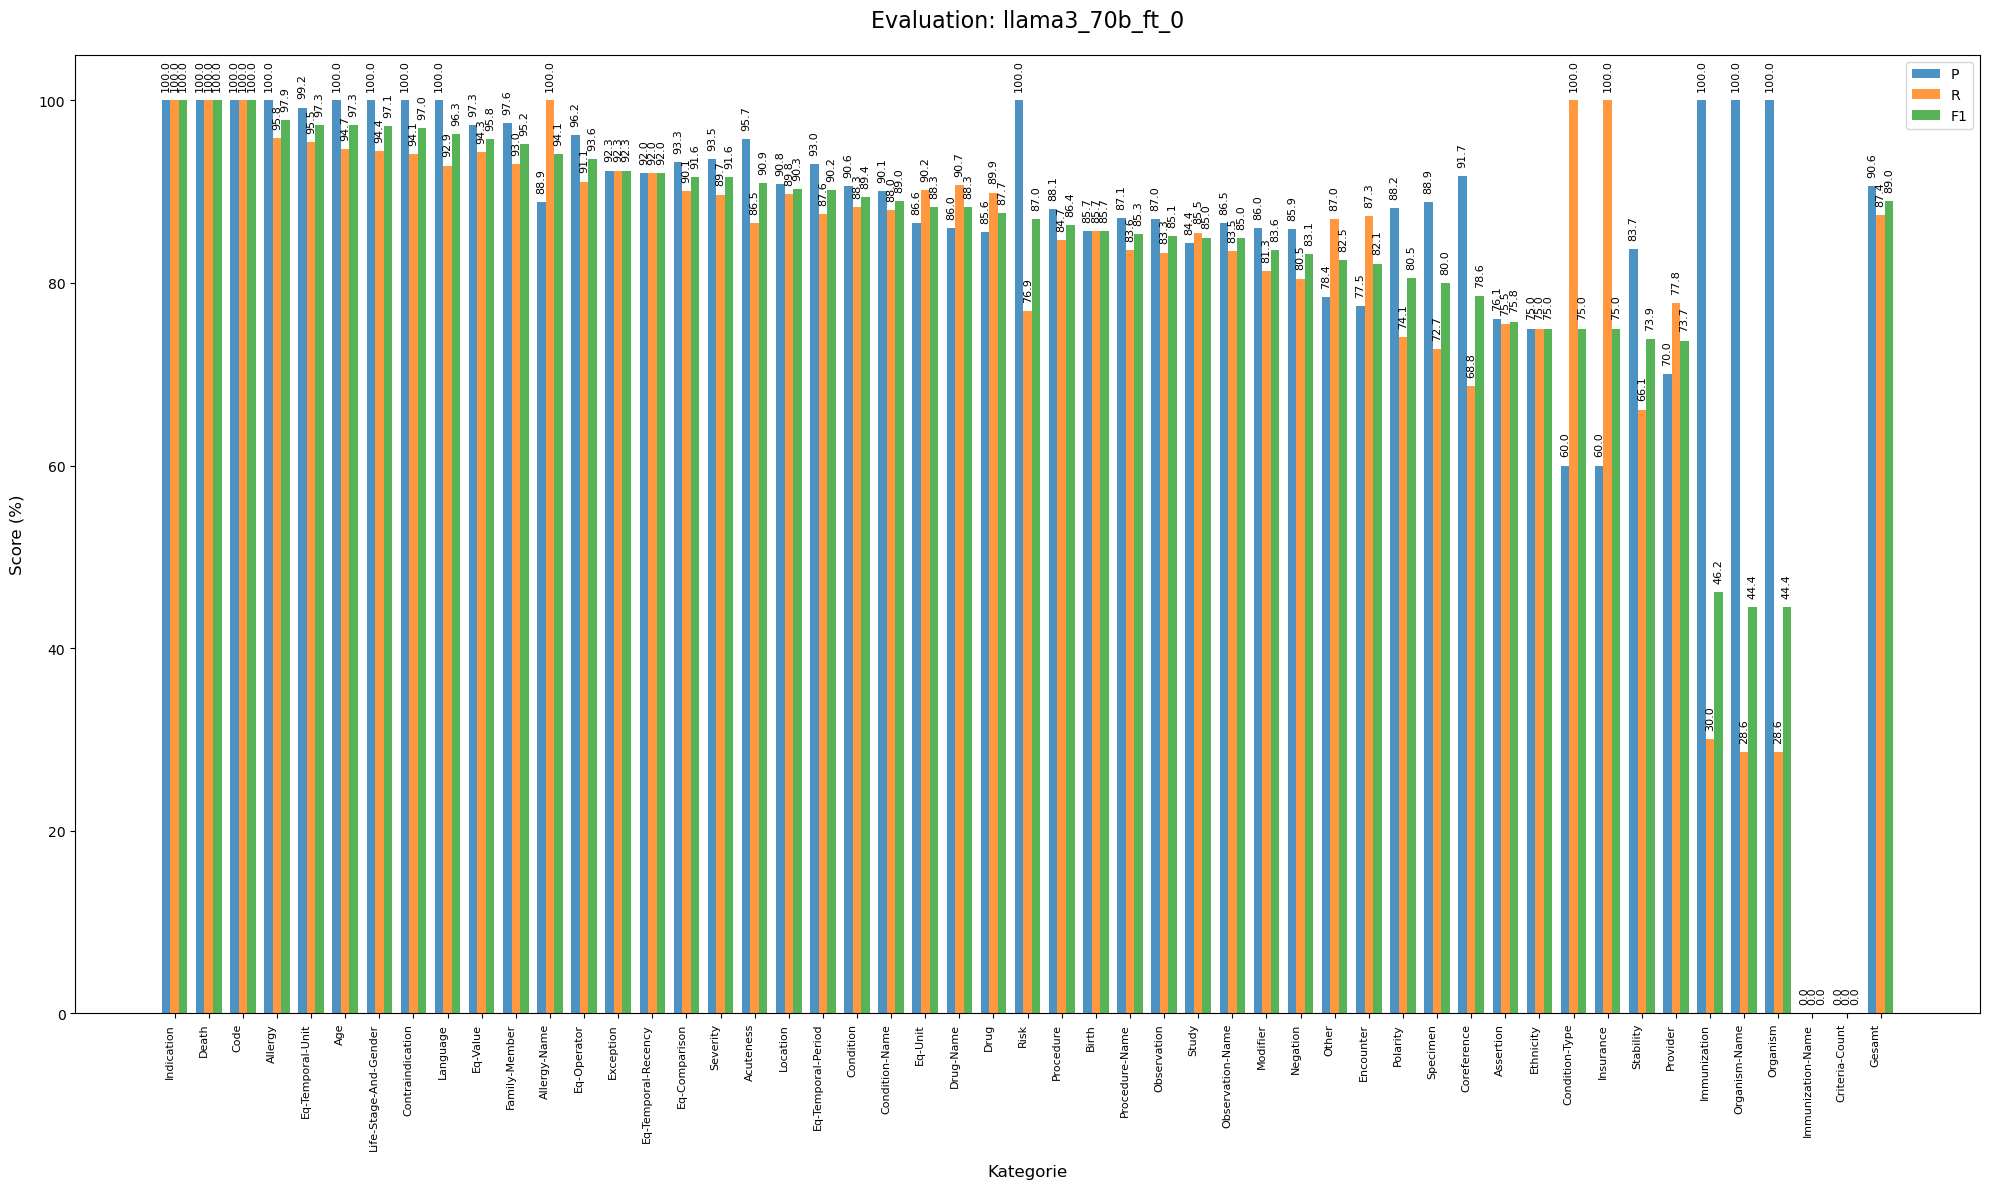

In [7]:
plot_metrics_all_entitys(models[0], metrics, categories)

### Calculate Metrics for AND OR NOT

### Calculate Operator Metrics and save to Latex

In [5]:
label_operator_folder = "../input/lct_p1_half_with_and/" # '../input/lct_p1_half/'
raw_lct_text_folder = '../input/lct_txt_half'
model_output_folder = f'{batch_path}/model_output/'
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'processed_output')
    metrics = evaluate_models(label_operator_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

NCT03860194_exc
Label AND: []
Label AND1: ['months', 'resident', 'failure', 'failure', 'mellitus']
Model  AND: ['months', 'resident', 'failure', 'failure', 'mellitus']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 5
Label AND: []
Label AND1: ['months', 'resident', 'failure', 'failure', 'mellitus']
Model  AND: ['months', 'resident', 'failure', 'failure', 'mellitus']
AND1
TP: 5, FP: 0, FN: 0, Label count: 5, Model count: 5
NCT03860194_inc
Label AND: []
Label AND1: ['years', 'Japan']
Model  AND: ['years', 'Japan']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 2
Label AND: []
Label AND1: ['years', 'Japan']
Model  AND: ['years', 'Japan']
AND1
TP: 2, FP: 0, FN: 0, Label count: 2, Model count: 2
NCT03860415_exc
Label AND: []
Label AND1: ['TNFalphainhibitors', 'care', 'immunodeficiency', 'disorder', 'abuse', 'dementia']
Model  AND: ['TNFalphainhibitors', 'care', 'immunodeficiency', 'disorder', 'abuse', 'dementia']
AND
TP: 0, FP: 0, FN: 0, Label count: 0, Model count: 6
Label AN

In [6]:
latex_operator_metrics_table(all_metrics)

'\\begin{table}[!ht]\n\\centering\n\\small\n\\begin{tabular}{llrrrrr}\n\\toprule\n\\textbf{Model} & \\textbf{Metrik} & \\multicolumn{4}{c}{\\textbf{Operator}} & \\textbf{Durchschnitt} \\\\\n\\cmidrule(lr){3-6}\n& & AND & AND1 & OR & NOT & \\\\\n\\midrule\nSOTA\n(SciBERT) & Precision & 54.1 & 0.0 & 85.1 & 74.3 & 71.2 \\\\\n & Recall & 60.0 & 0.0 & 93.2 & 91.0 & 81.4 \\\\\n & F1-Score & 56.9 & 0.0 & 89.0 & 81.8 & 75.9 \\\\\n\\midrule\nLlama3 70B\n(Fine-Tuned) & Precision & 67.7 & 96.3 & 92.6 & 87.7 & 82.7 \\\\\n & Recall & 72.3 & 95.8 & 89.1 & 83.6 & 81.7 \\\\\n & F1-Score & 69.9 & 96.0 & 90.8 & 85.6 & 82.1 \\\\\n\\midrule\nLlama3 70B\n(Fine-Tuned) & Precision & 67.3 & 96.1 & 92.7 & 88.9 & 83.0 \\\\\n & Recall & 77.1 & 95.5 & 89.0 & 82.8 & 83.0 \\\\\n & F1-Score & 71.8 & 95.8 & 90.9 & 85.7 & 82.8 \\\\\n\\midrule\nLlama3 70B\n(Fine-Tuned) & Precision & 65.9 & 95.8 & 91.9 & 85.1 & 81.0 \\\\\n & Recall & 78.6 & 95.7 & 89.7 & 83.6 & 84.0 \\\\\n & F1-Score & 71.7 & 95.7 & 90.8 & 84.4 & 82.3 \

## Plot Operator Metrics

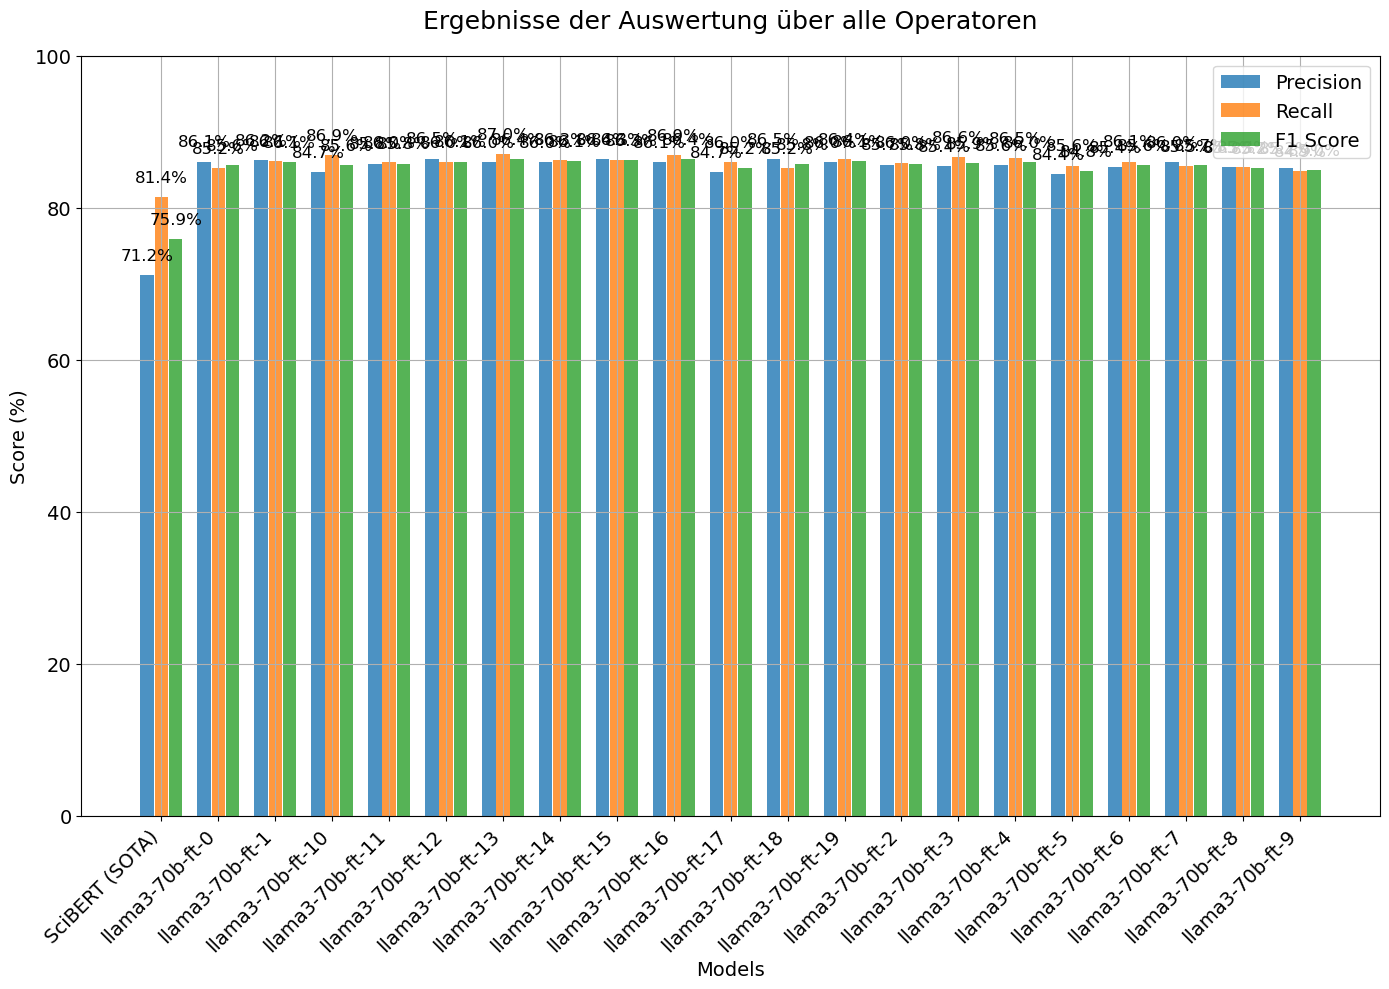

In [7]:
plot_avg_metrics(all_metrics)

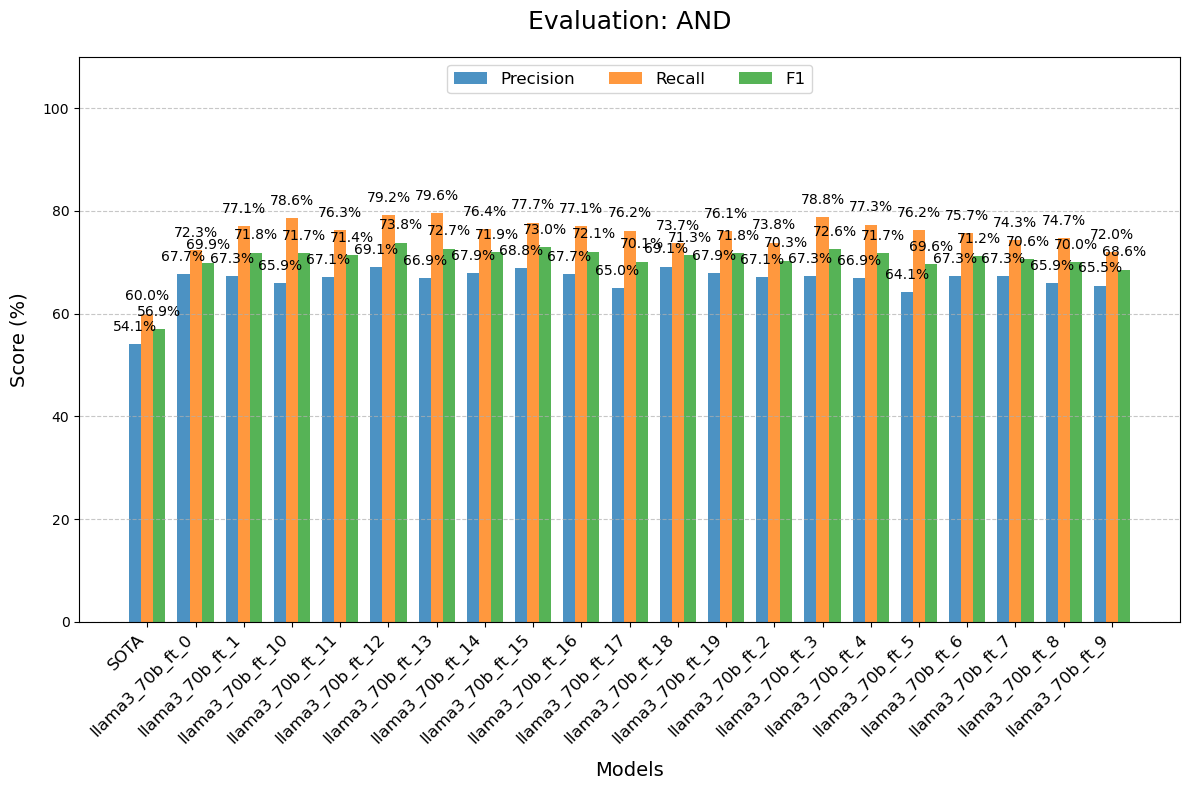

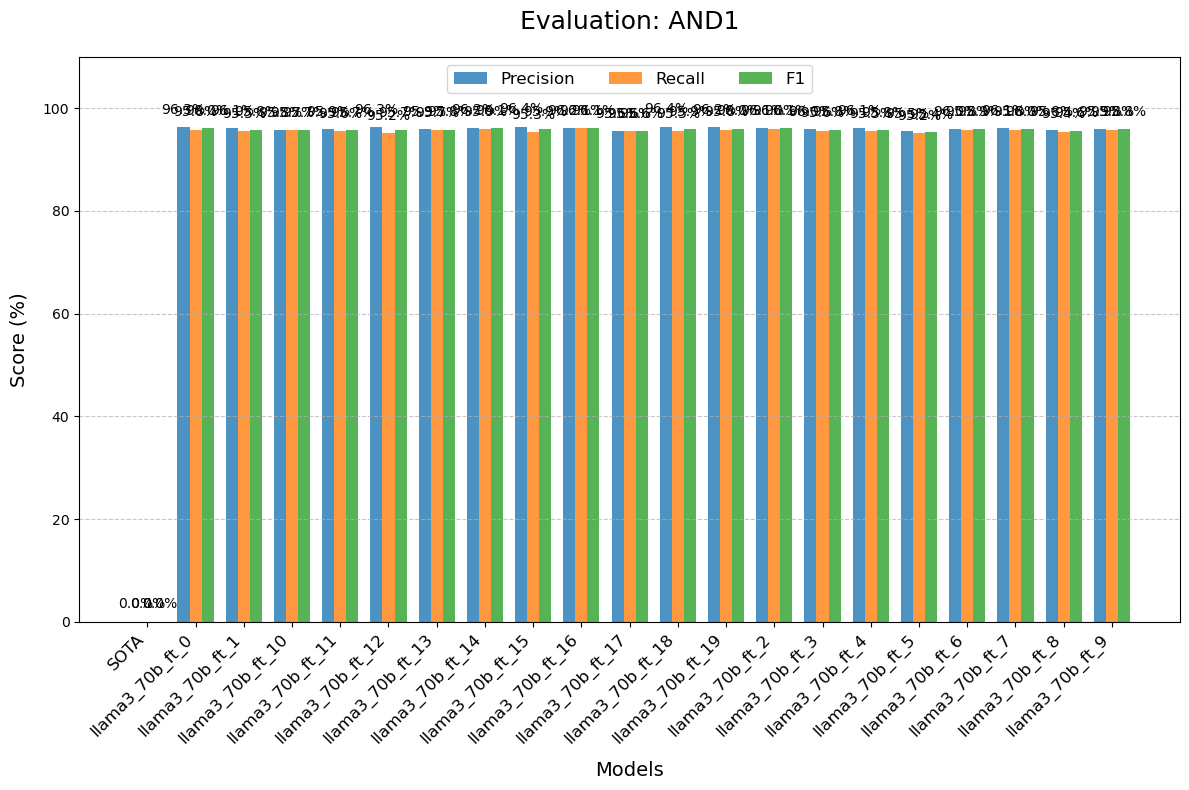

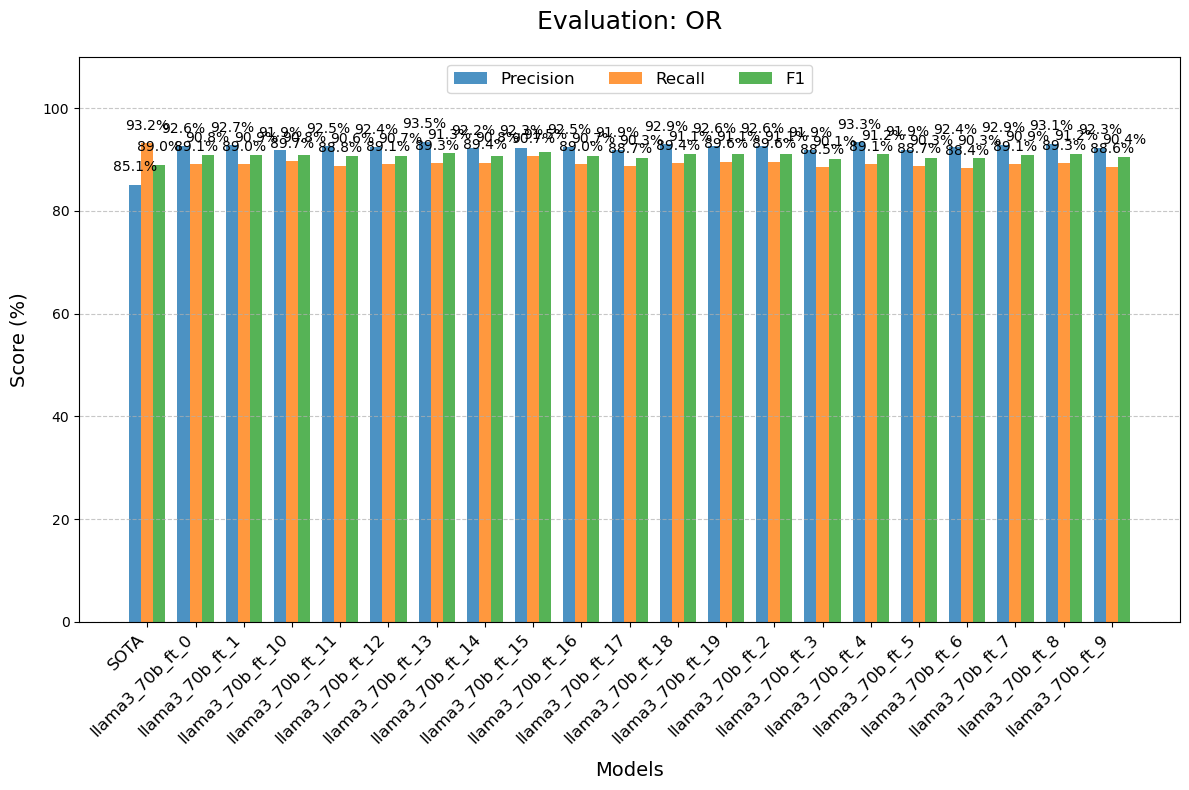

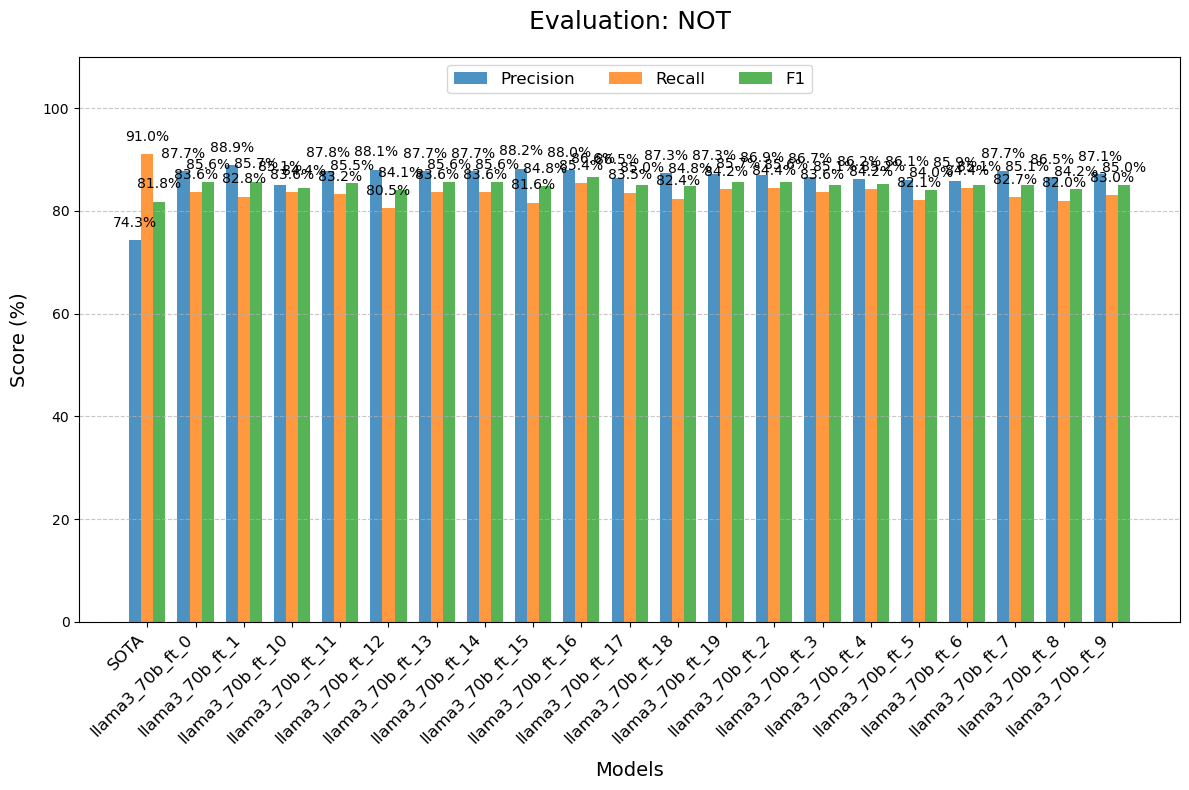

In [8]:
plot_operator_metrics(all_metrics)